In [1]:
# %%
import torch
import numpy as np
import normflows as nf
from tqdm import tqdm
import pandas as pd

# seed = 0
# torch.manual_seed(seed)
# np.random.seed(seed)
# torch.no_grad()

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.join(c_directory, 'FCYeast2'))

from matplotlib import pyplot as plt
import FCYeast_extrinsic_simulator
import architecture

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
g3 = np.loadtxt('../Real/FCYeast2_MCMC/mcmc_real_results_116224datapoints.csv')[-100000:,:]
map_index = np.argmax(g3[:,-1])
best_param = torch.tensor(g3[map_index]).float().to(device)
gt_high, gt_low = FCYeast_extrinsic_simulator.transform_to_arbitrary(best_param).cpu().numpy()


gt_sets = {"high": gt_high, "low": gt_low}

In [3]:

seed = 2


lem_high = np.loadtxt('oblation_mcmc_results/mcmc_results_high_{}.csv'.format(seed))
lem_low = np.loadtxt('oblation_mcmc_results/mcmc_results_low_{}.csv'.format(seed))
dv_high = pd.read_csv(f'oblation_simulations/sim_high_seed{seed}.csv')
dv_low  = pd.read_csv(f'oblation_simulations/sim_low_seed{seed}.csv')

data_high_stress = np.array(dv_high['lI'].dropna().values)
data_low_stress = np.array(dv_low['lI'].dropna().values)




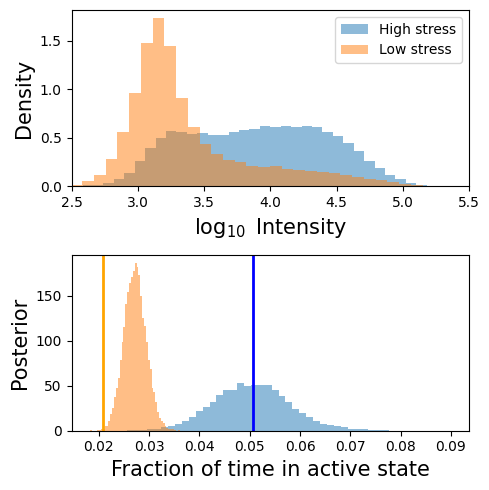

In [4]:


fig, axs = plt.subplots(2, 1, figsize=(5, 5))

# === High stress ===
t_active   = np.exp(lem_high[:, 1])
t_inactive = np.exp(lem_high[:, 2])
frac_active = t_active / (t_active + t_inactive)

axs[1].hist(frac_active, bins=50, density=True,alpha=.5)
gt_frac_active = np.exp(gt_high[1]) / (np.exp(gt_high[1]) + np.exp(gt_high[2]))
axs[1].axvline(gt_frac_active, color='blue', lw=2)


# === Low stress ===
t_active   = np.exp(lem_low[:, 1])
t_inactive = np.exp(lem_low[:, 2])
frac_active = t_active / (t_active + t_inactive)

axs[1].hist(frac_active, bins=50, density=True,alpha=.5)
gt_frac_active = np.exp(gt_low[1]) / (np.exp(gt_low[1]) + np.exp(gt_low[2]))
axs[1].axvline(gt_frac_active, color='orange', lw=2)

axs[1].set_xlabel('Fraction of time in active state',fontsize=15)
axs[1].set_ylabel("Posterior",fontsize=15)

l10 = np.log(10)
axs[0].hist(data_high_stress/l10, bins=50, density=True, alpha=.5, label='High stress')
axs[0].hist(data_low_stress/l10, bins=50, density=True, alpha=.5, label='Low stress')
axs[0].legend()
axs[0].set_xlabel(r'$\log_{10}$ Intensity',fontsize=15)
axs[0].set_ylabel("Density",fontsize=15)

axs[0].set_xlim(2.5,5.5)
plt.tight_layout()
plt.savefig('Intensity_fraction.png',dpi=500)


plt.show()



In [5]:
betas_high_stress = np.array(dv_high['betas'].dropna().values)
betas_low_stress = np.array(dv_low['betas'].dropna().values)

(array([3.08279262e-02, 4.50209813e-01, 3.07363581e+00, 8.21274267e+00,
        1.05440664e+01, 6.63014072e+00, 2.12285373e+00, 4.03815310e-01,
        5.64669935e-02, 5.49408585e-03]),
 array([6.14807735, 6.17979292, 6.21150849, 6.24322406, 6.27493963,
        6.3066552 , 6.33837078, 6.37008635, 6.40180192, 6.43351749,
        6.46523306]),
 <BarContainer object of 10 artists>)

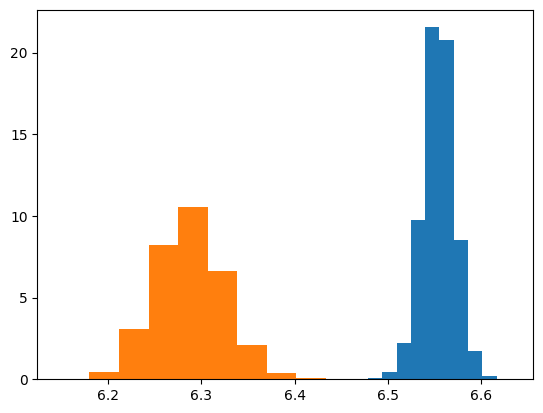

In [6]:
plt.hist(np.log10(betas_low_stress),density=True)
plt.hist((lem_low[:, 0])/np.log(10),density=True)

(array([0.01795939, 0.31974425, 2.22343941, 6.07312662, 5.46015759,
        2.41948208, 0.65811927, 0.1278977 , 0.03239404, 0.00621026]),
 array([6.221427  , 6.27910201, 6.33677703, 6.39445204, 6.45212706,
        6.50980207, 6.56747709, 6.6251521 , 6.68282711, 6.74050213,
        6.79817714]),
 <BarContainer object of 10 artists>)

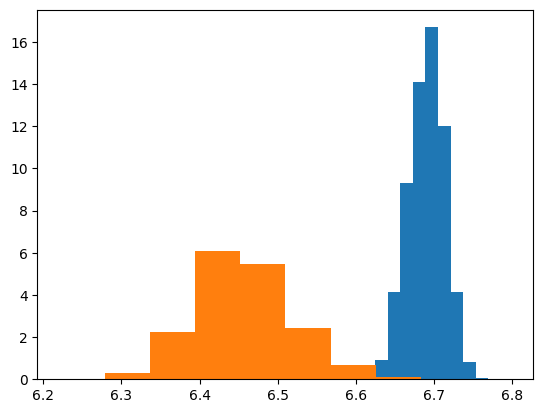

In [7]:
plt.hist(np.log10(betas_high_stress),density=True)
plt.hist((lem_high[:, 0])/np.log(10),density=True)

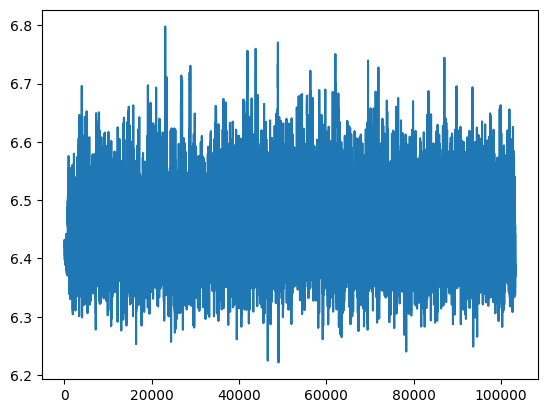

In [10]:
plt.plot((lem_high[:, 0])/np.log(10))

In [9]:
lem_high[:, 0]

array([14.78930092, 14.78930092, 14.78930092, ..., 14.71223259,
       14.71223259, 14.71223259], shape=(103301,))